# Target Visibility Checker
- **Cell 1** — imports.  The helper functions live in `helpers.py` beside this
  notebook.
- **Cell 2** — everything you edit: `targets_list`, the UTC start/stop, the
  cadence in minutes, and the `Visibility` instance (default keep-outs).
- **Cell 3** — per-target visibility from `get_visibility_best_roll`, with a
  statistics summary and, for planets, how much of each transit and secondary
  eclipse is observable.
- **Cell 4** — one timeline for all targets: a green line wherever the target
  is visible, over blue transit and purple eclipse boxes.
- **Cell 5** — per-target breakdown of which constraint is failing while the
  target is not visible.

Name a planet rather than a star — `"WASP-107 b"`, `"TRAPPIST-1 b"` — and the
NASA Exoplanet Archive is queried for its ephemeris so transits and secondary
eclipses can be overlaid.  A trailing **lowercase** letter marks the planet; a
trailing uppercase letter is a binary component and stays part of the star
name, so `"WASP-160 B"` is a star and `"WASP-160 B b"` is its planet.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from astropy import units as u
from matplotlib.patches import Patch

from helpers import (
    ECLIPSE_COLOR,
    TRANSIT_COLOR,
    build_time_grid,
    draw_event_box,
    draw_row,
    event_segments,
    event_visibility_stats,
    format_date_axis,
    label_rows,
    mask_segments,
    predict_events,
    prepare_targets,
    run_stats,
)
from pandoravisibility import Visibility

## Edit this cell

`targets_list` accepts star names (looked up in SIMBAD), planet names ending in
a lowercase letter (looked up in SIMBAD *and* the NASA Exoplanet Archive),
decimal-degree pairs, and sexagesimal string pairs — mix them freely.

In [2]:
# Targets
# targets_list = [
#     "GJ 1214",                       # name → looked up in SIMBAD
#     "WASP-80",
#     "TOI-836",
#     "KELT-9",                        # inside the Sun keep-out all day here
#     "WASP-107 b",                    # planet → transit + eclipse overlay
#     "WASP-107 c",                    # known planet, does not transit → warning
#     "WASP-160 B b",                  # planet of the B component of a binary
#     (255.0, 10.0),                   # RA, Dec in decimal degrees
#     ("17h00m00s", "-30d00m00s"),     # RA, Dec as sexagesimal strings
# ]

targets_list = [
    "HD209458 b",
    "WASP-69 b",
    "KELT-9 b",
    "HAT-P-67 b",
    "GJ 12 b ",
    "K2-141 b",
    # "KELT-20 b",
    # "GJ 9827 b",
    # "HD221416 b",
    # "TOI-1533 c",
    # "WASP-52 b",
    # "WASP-127 b"
]
targets_list = [
"GJ 1214 b",
"GJ 3470 b",
"GJ 436 b",
"GJ 806 b",
"HAT-P-11 b",
"HAT-P-12 b",
"HAT-P-17 b",
"HAT-P-18 b",
"HAT-P-19 b",
"HAT-P-26 b",
"HAT-P-44 b",
"HATS-72 b",
"HD 110067 b",
"HD 189733 b",
"HD 207496 b",
"HD 260655 b",
"HD 260655 c",
"L 98-59 b",
"L 98-59 d",
"TOI-1064 c",
"TOI-1130 c",
"TOI-1268 b",
"TOI-1803 c",
"TOI-1807 b",
"TOI-181 b",
"TOI-2076 b",
"TOI-2134 b",
"TOI-216.02",
"TOI-2443 b",
"TOI-2876 b",
"TOI-3486 b",
"TOI-3884 b",
"TOI-4010 c",
"TOI-421 c",
"TOI-431 d",
"TOI-544 b",
"TOI-5789 c",
"TOI-674 b",
"TOI-700 c",
"TOI-880 c",
"TrES-1 b",
"V1298 Tau c",
"V1298 Tau d",
"WASP-107 b",
"WASP-29 b",
"WASP-52 b",
"WASP-69 b",
"WASP-80 b",
"WASP-84 b",
"XO-2 N b"
]


# Time window (UTC) and cadence
start_utc = "2026-08-10T00:00:00"
stop_utc = "2027-02-10T00:00:00"
time_step_minutes = 1.0

# Spacecraft orbit
# Draft TLE for Pandora — use the most up-to-date one for real work!
line1 = "1 67395U 80229J   26216.70819444  .00000000  00000-0  37770-3 0    05"
line2 = "2 67395  97.8080 214.6153 0004926 345.1411 322.7976 14.88095475    03"

# Default keep-outs: Sun ≥ 91°, Moon ≥ 25°, Earth limb ≥ 20°, no star
# tracker limits.  Pass overrides here to tighten anything, e.g.
# Visibility(line1, line2, earthlimb_day_min=45*u.deg, st_sun_min=44*u.deg).
visibility = Visibility(
    line1, line2,
    earthlimb_day_min=44 * u.deg,
    earthlimb_night_min=13 * u.deg,
    sun_min=91 * u.deg,
    moon_min=20 * u.deg,
    st_sun_min=45 * u.deg,
    st_moon_min=0 * u.deg,
    st_earthlimb_min=0 * u.deg,
    st_required=1,
    use_dynamic_earthlimb=True,
    use_dynamic_earthlimb_st=False,
    # Sun/Moon evaluated hourly and interpolated instead of at every
    # timestep.  Their directions stay good to well under 0.01 deg, and
    # long multi-target runs get several times faster.  Drop this line to
    # evaluate the ephemeris exactly.
    ephemeris_step=60 * u.min,
)

# Roll sweep settings for get_visibility_best_roll.  These only bite once
# star tracker keep-outs are active, which the defaults leave switched off.
roll_step = 2 * u.deg
orbit_time_step = 1 * u.min

times = build_time_grid(start_utc, stop_utc, time_step_minutes)

print(visibility)
print(f"Orbital period: {visibility.get_period():.2f}")
print(f"{len(times)} steps of {time_step_minutes:g} min: "
      f"{times[0].iso} → {times[-1].iso}")

<Visibility: SAT67395 [moon≥20 deg, sun≥91 deg, limb=dynamic, st_sun≥45 deg, st_req=1]>
Orbital period: 96.77 min
264960 steps of 1 min: 2026-08-10 00:00:00.000 → 2027-02-09 23:59:00.000


## Visibility per target

`get_visibility_best_roll` picks the best fixed roll angle for each orbit and
reports visibility at every time step.

For any target named as a planet, the transits and secondary eclipses falling
in the window are listed with the fraction of each event that is observable.
Events touching the edge of the window are marked `*`; only the sampled part of
those counts towards the percentage.

In [3]:
targets = prepare_targets(targets_list)
results = {}

header = (
    f"{'Target':<24}{'Visible':>13}{'Duty':>8}{'Windows':>9}{'Longest':>10}"
)
print(header)
print("-" * len(header))

for target in targets:
    label = target["label"]

    best_roll = visibility.get_visibility_best_roll(
        target["coord"], times, roll_step=roll_step, orbit_time_step=orbit_time_step,
    )
    visible = np.asarray(best_roll["visible"])
    n_windows, longest_minutes = run_stats(times, visible, time_step_minutes)

    # Transits and secondary eclipses inside the window, when this target
    # was named as a planet the archive has an ephemeris for.
    events = {}
    if target["ephemeris"] is not None:
        for kind in ("transit", "eclipse"):
            ephemeris = target["ephemeris"][kind]
            if ephemeris is not None:
                events[kind] = predict_events(ephemeris, target["coord"], times)

    results[label] = {
        "coord": target["coord"],
        "visible": visible,
        "best_roll": best_roll,
        "events": events,
    }

    print(
        f"{label:<24}"
        f"{f'{visible.sum()} / {len(times)}':>13}"
        f"{100 * visible.mean():>7.1f}%"
        f"{n_windows:>9}"
        f"{longest_minutes:>8.0f} m"
    )

roll_used = np.concatenate([r["best_roll"]["roll_deg"].ravel() for r in results.values()])
if np.isfinite(roll_used).any():
    print(f"\nMedian roll angle used: {np.nanmedian(roll_used):.1f} deg")
else:
    print("\nNo roll angle selected (no star tracker constraints active).")

# Transit and secondary eclipse coverage
print_event_details = False
if any(result["events"] for result in results.values()):
    print("\nTransit and secondary eclipse coverage")
    for label, result in results.items():
        for kind, events in result["events"].items():
            if not events:
                print(f"  {label} — no {kind} in this window")
                continue
            stats = event_visibility_stats(events, result["visible"])
            fully = sum(1 for f in stats["fractions"] if f >= 1.0)
            print(
                f"  {label} — {stats['n_events']} {kind}s "
                f"({stats['n_full']} complete), "
                f"{100 * stats['visible_fraction']:.1f}% of {kind} time visible, "
                f"{fully} fully observable"
            )
            if print_event_details:
                for event, fraction in zip(events, stats["fractions"]):
                    edge = "*" if event["clipped"] else " "
                    print(
                        f"      {event['mid'].iso[:16]} UTC{edge} "
                        f"{event['start'].iso[11:16]}-{event['stop'].iso[11:16]}  "
                        f"{100 * fraction:5.1f}% visible"
                    )

Target                        Visible    Duty  Windows   Longest
----------------------------------------------------------------
GJ 1214 b               21777 / 264960    8.2%      451      49 m
GJ 3470 b               102038 / 264960   38.5%     1155   25016 m
GJ 436 b                52473 / 264960   19.8%      948      60 m
GJ 806 b                92385 / 264960   34.9%     1613      63 m
HAT-P-11 b              79293 / 264960   29.9%     1395      61 m
HAT-P-12 b              35872 / 264960   13.5%      649      57 m
HAT-P-17 b              102412 / 264960   38.7%     1684      71 m
HAT-P-18 b              15480 / 264960    5.8%      321      49 m
HAT-P-19 b              135407 / 264960   51.1%     2330      68 m
HAT-P-26 b              15452 / 264960    5.8%      295      56 m
HAT-P-44 b              35518 / 264960   13.4%      641      57 m
HATS-72 b               88978 / 264960   33.6%     1446      70 m
HD 110067 b             38916 / 264960   14.7%      716      58 m
HD 189733

## When is each target visible?

A green line means the target clears every constraint at that time step.  Blue
boxes are transits and purple boxes are secondary eclipses, so green sitting
inside a box is an observable event.

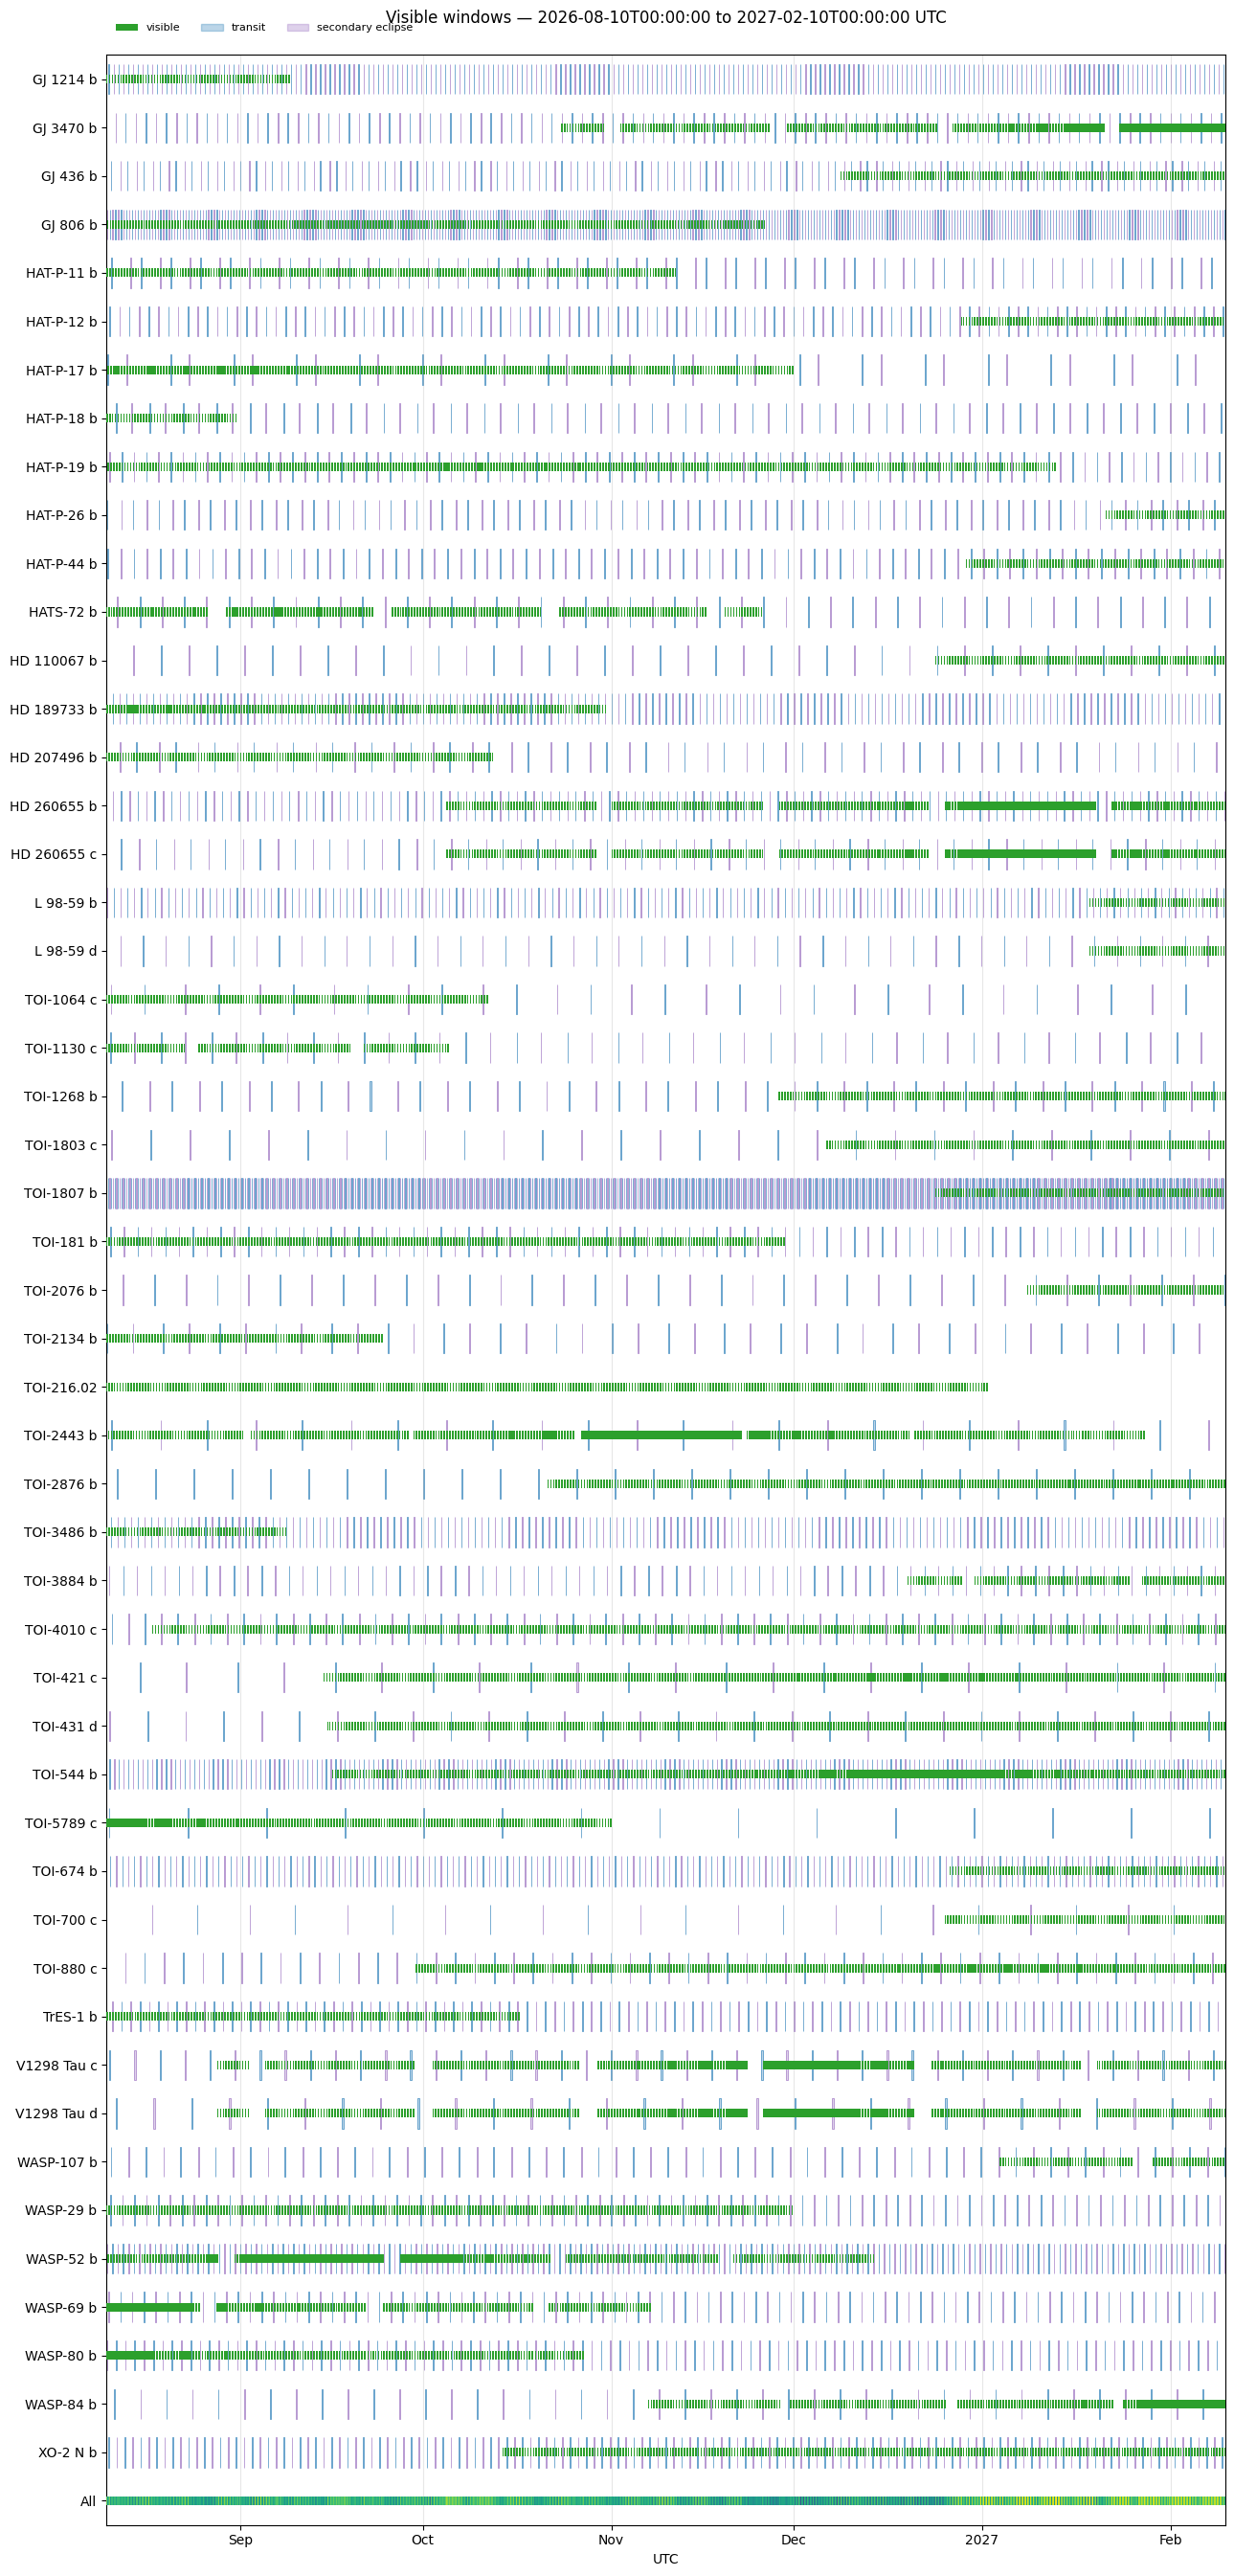

In [4]:
fig, ax = plt.subplots(figsize=(13, 0.5 * len(results) + 2.0))

all_ = np.zeros(results[list(results.keys())[0]]["visible"].size, dtype=int)
for row, result in enumerate(results.values()):
    for kind, color in (("transit", TRANSIT_COLOR), ("eclipse", ECLIPSE_COLOR)):
        events = result["events"].get(kind)
        if events:
            draw_event_box(
                ax, row,
                event_segments(events, min_width_minutes=time_step_minutes),
                color,
            )
    draw_row(
        ax, row,
        mask_segments(times, result["visible"], time_step_minutes),
        "tab:green",
    )
    all_ += result["visible"]

# draw_row(
#         ax, len(results),
#         mask_segments(times, all_, time_step_minutes),
#         "tab:green",
#     )

colors = plt.get_cmap("viridis")(np.linspace(0, 1, np.max(all_)))
for i in range(np.max(all_)):
    mask_ = all_ == i
    color_ = colors[i]
    draw_row(
        ax, len(results),
        mask_segments(times, mask_, time_step_minutes),
        color_,
    )

results_names = list(results) + ['All']
label_rows(ax, results_names)
format_date_axis(ax, times)
ax.set_title(f"Visible windows — {start_utc} to {stop_utc} UTC", pad=24)

handles = [Patch(facecolor="tab:green", label="visible")]
if any(result["events"] for result in results.values()):
    handles += [
        Patch(facecolor=TRANSIT_COLOR, alpha=0.30, edgecolor=TRANSIT_COLOR,
              label="transit"),
        Patch(facecolor=ECLIPSE_COLOR, alpha=0.30, edgecolor=ECLIPSE_COLOR,
              label="secondary eclipse"),
    ]
ax.legend(handles=handles, loc="lower left", bbox_to_anchor=(0.0, 1.005),
          ncols=len(handles), fontsize=8, frameon=False)
plt.tight_layout()
plt.show()

In [13]:
results['GJ 1214 b']['visible']
import pickle
with open("results.pkl", "wb") as f:
    pickle.dump(results, f)

In [14]:
results['GJ 1214 b'].keys()


dict_keys(['coord', 'visible', 'best_roll', 'events'])

## Which constraint is failing?

For each target, a bar marks the time steps where that row fails; the grey row
at the bottom is the overall "not visible" result for comparison.

**Red rows are binding** — the step is lost when one of them fails.  **Amber
rows are per-tracker detail** from `get_star_tracker_breakdown`: which star
tracker is failing which keep-out, and by how many steps.  With
`st_required=1` a single tracker failing is *not* fatal, because the other
one can cover it, so only the red `star tracker` row underneath is binding.
Set `st_required=2` and every amber row becomes binding.  The amber rows share
their geometry with the red `star tracker` row, so ANDing one tracker's amber
rows always reproduces that tracker's overall verdict.

`get_all_constraints` shares its ephemeris and geometry with `get_visibility`,
so the boresight rows account for every boresight failure exactly.  The star
tracker rows are different: they are evaluated at the default Sun-constrained
attitude, one step at a time, while the grey row comes from
`get_visibility_best_roll`, which holds a single roll angle for a whole orbit.
A step can therefore be marked not visible while every row here passes — the
orbit's fixed roll failed a tracker even though a per-step attitude would not
have.  The printout counts those.

GJ 1214 b: not visible at 243183 of 264960 steps
    moon           fails at     0 steps
    sun            fails at 221341 steps
    earthlimb      fails at 172033 steps
    star tracker   fails at     0 steps  (needs either tracker)
      ST1            fails at     0 steps
        sun        <      45 deg at     0 steps
      ST2            fails at     0 steps
        sun        <      45 deg at     0 steps
GJ 3470 b: not visible at 162922 of 264960 steps
    moon           fails at 25726 steps
    sun            fails at 107304 steps
    earthlimb      fails at 104501 steps
    star tracker   fails at     0 steps  (needs either tracker)
      ST1            fails at     0 steps
        sun        <      45 deg at     0 steps
      ST2            fails at     0 steps
        sun        <      45 deg at     0 steps
GJ 436 b: not visible at 212487 of 264960 steps
    moon           fails at     0 steps
    sun            fails at 173290 steps
    earthlimb      fails at 148891 steps


C:\Users\jrenaud\AppData\Local\Temp\1\ipykernel_2724\2027280305.py:60: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(figsize=(13, 0.4 * len(rows) + 1.8))


TOI-1130 c: not visible at 223417 of 264960 steps
    moon           fails at 22177 steps
    sun            fails at 183675 steps
    earthlimb      fails at 152714 steps
    star tracker   fails at     0 steps  (needs either tracker)
      ST1            fails at     0 steps
        sun        <      45 deg at     0 steps
      ST2            fails at     0 steps
        sun        <      45 deg at     0 steps
TOI-1268 b: not visible at 203744 of 264960 steps
    moon           fails at     0 steps
    sun            fails at 158968 steps
    earthlimb      fails at 133260 steps
    star tracker   fails at     0 steps  (needs either tracker)
      ST1            fails at     0 steps
        sun        <      45 deg at     0 steps
      ST2            fails at     0 steps
        sun        <      45 deg at     0 steps
TOI-1803 c: not visible at 210691 of 264960 steps
    moon           fails at     0 steps
    sun            fails at 170442 steps
    earthlimb      fails at 144492 st

KeyboardInterrupt: 

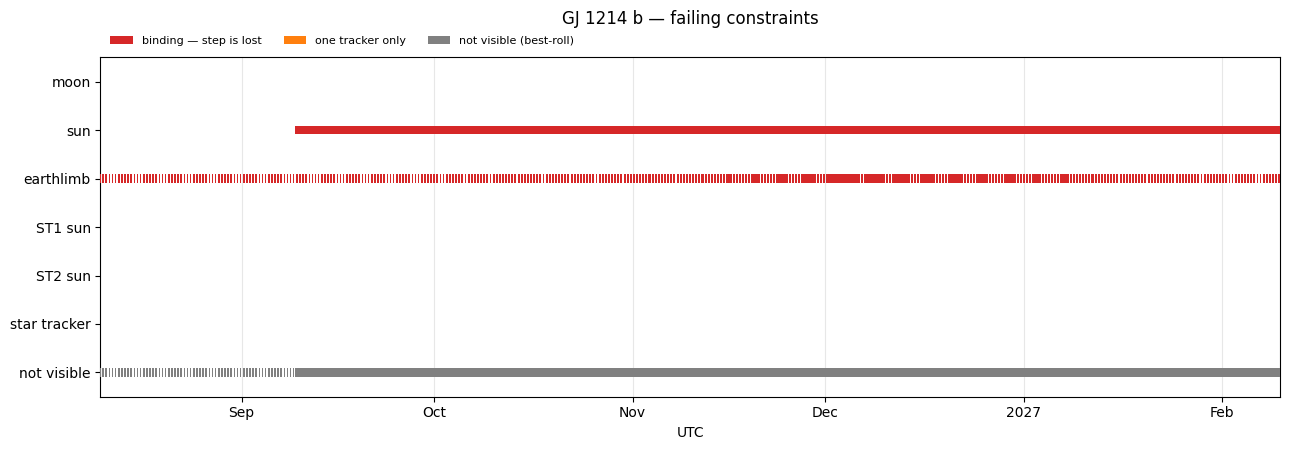

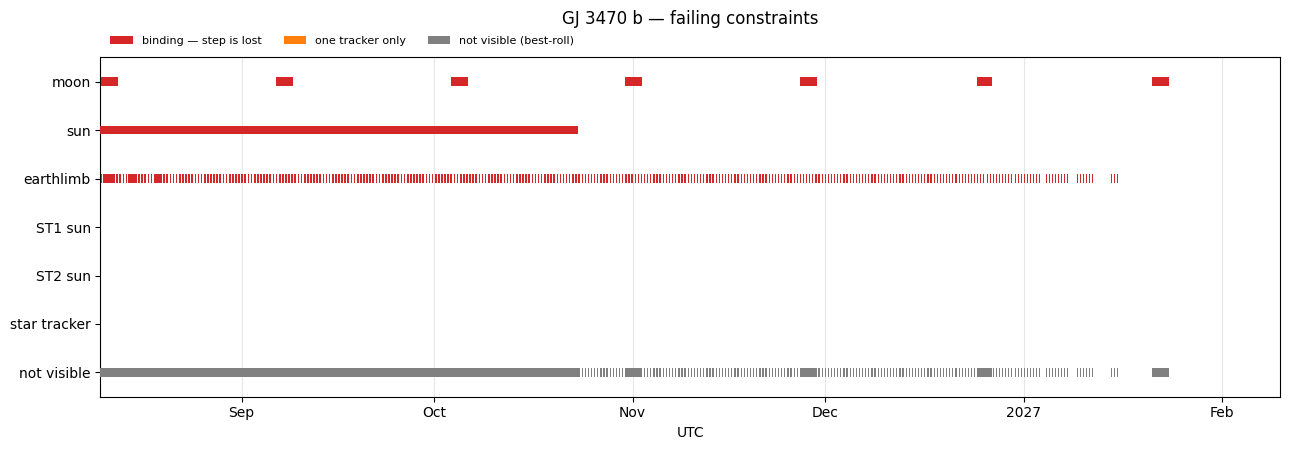

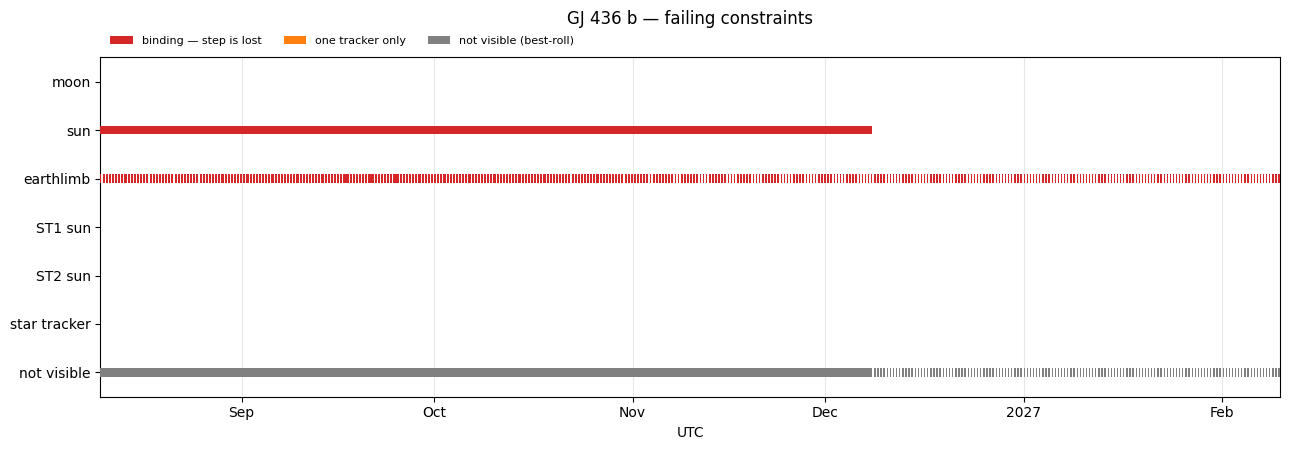

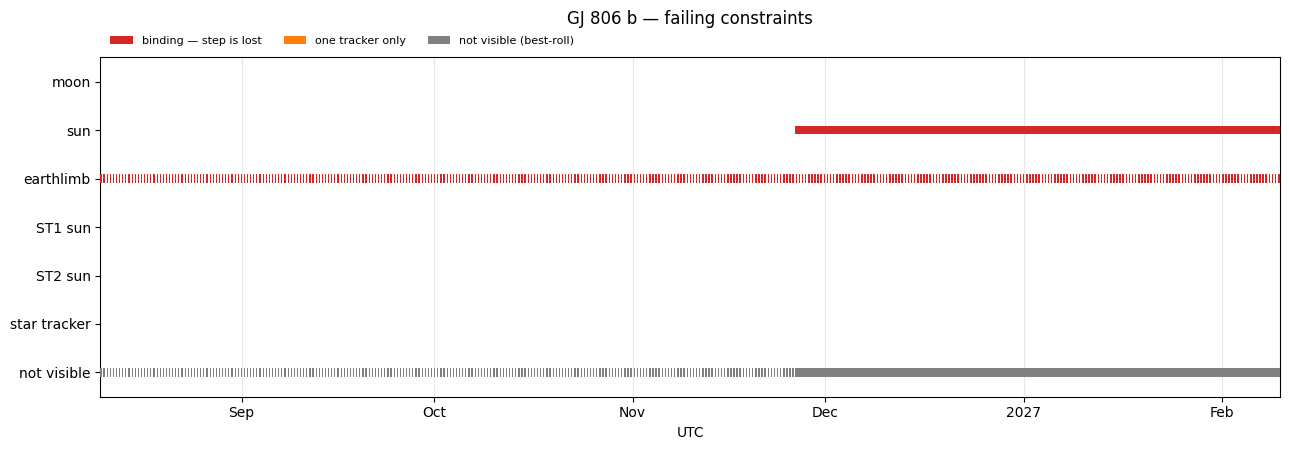

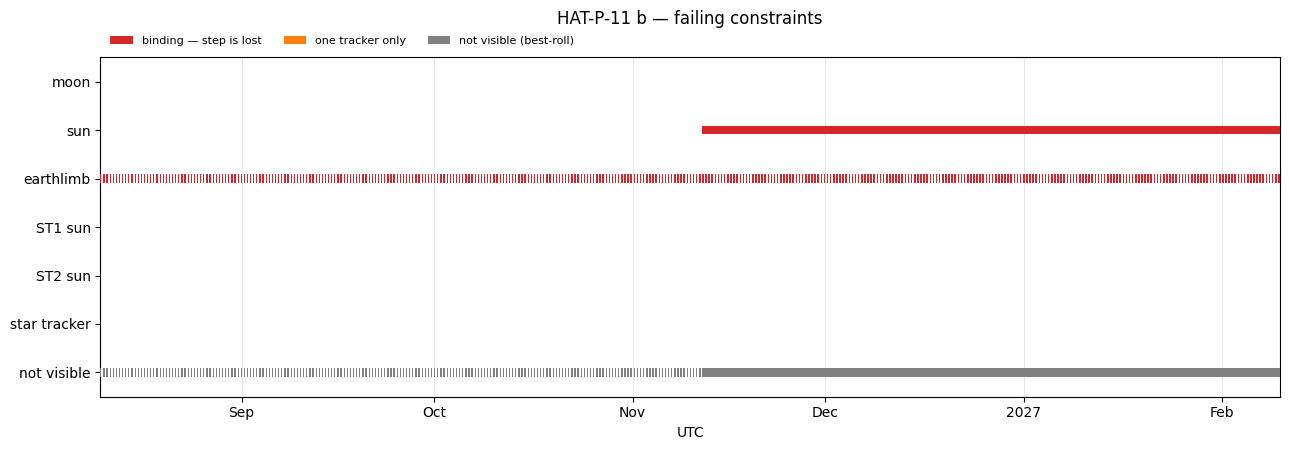

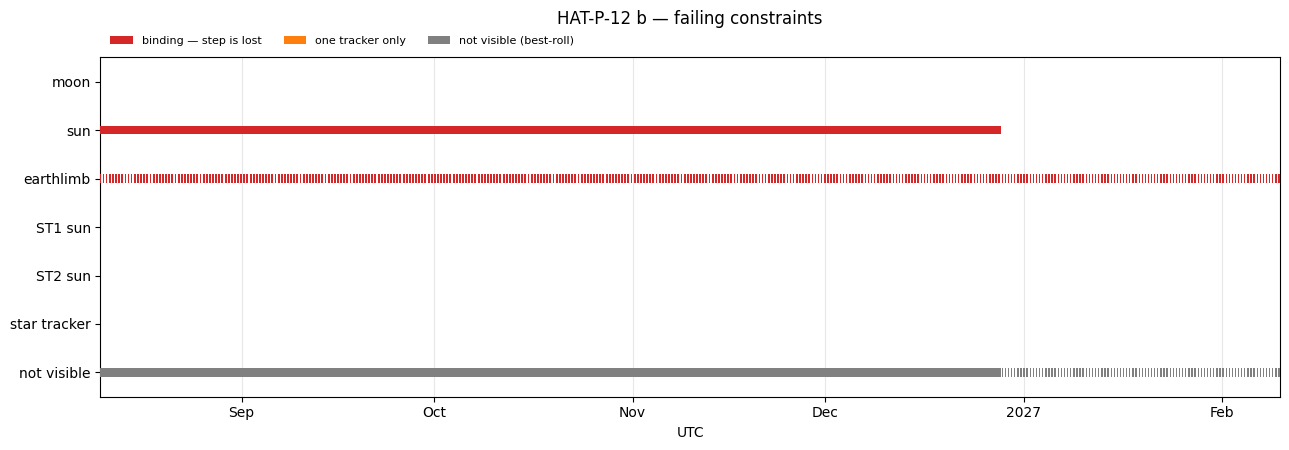

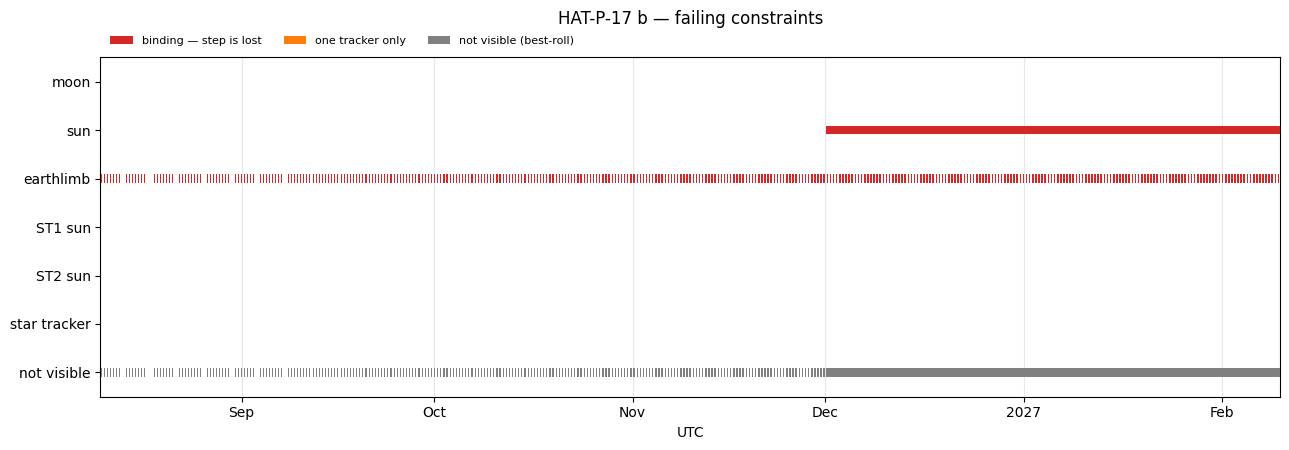

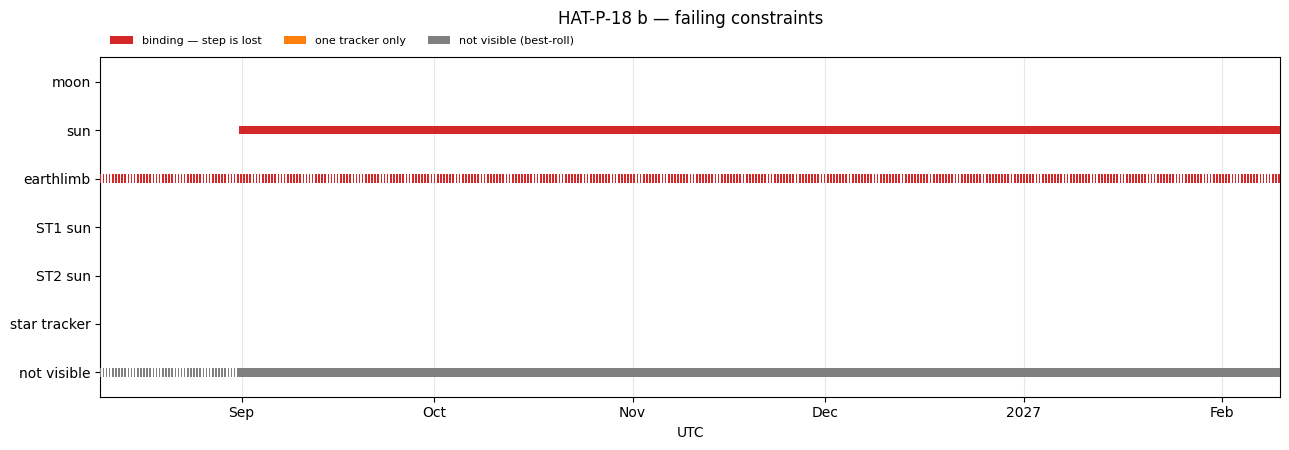

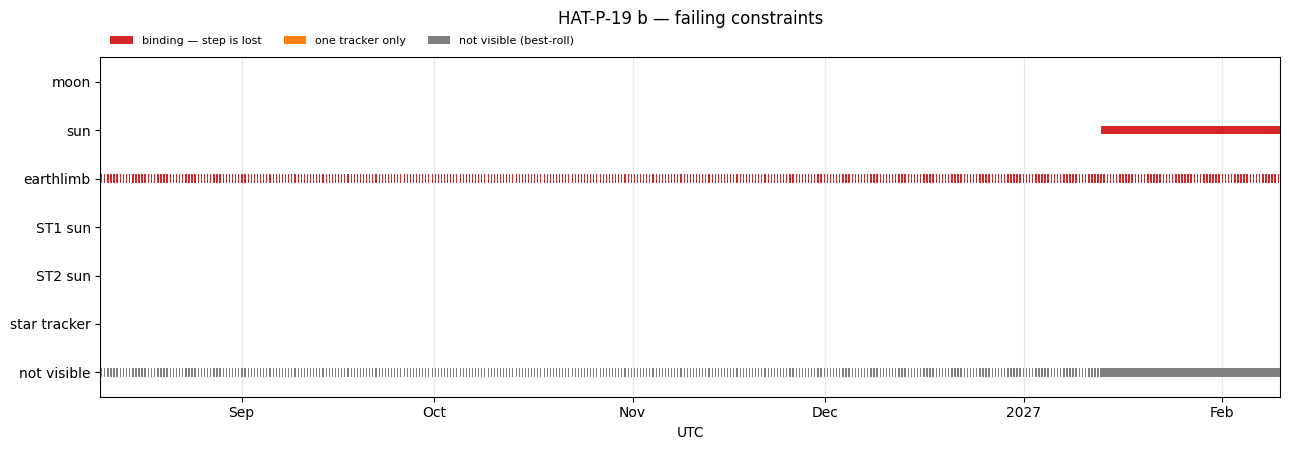

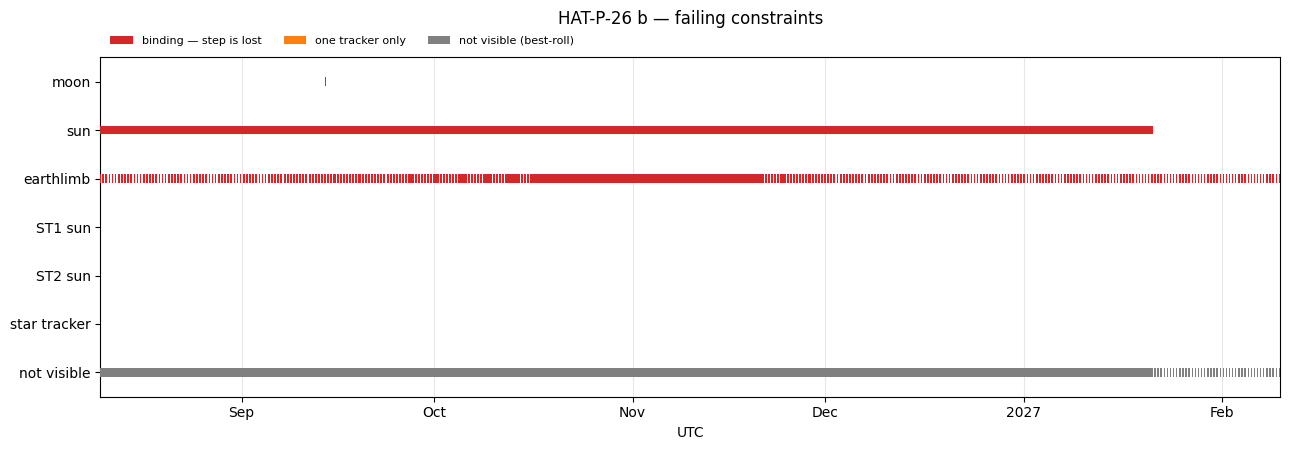

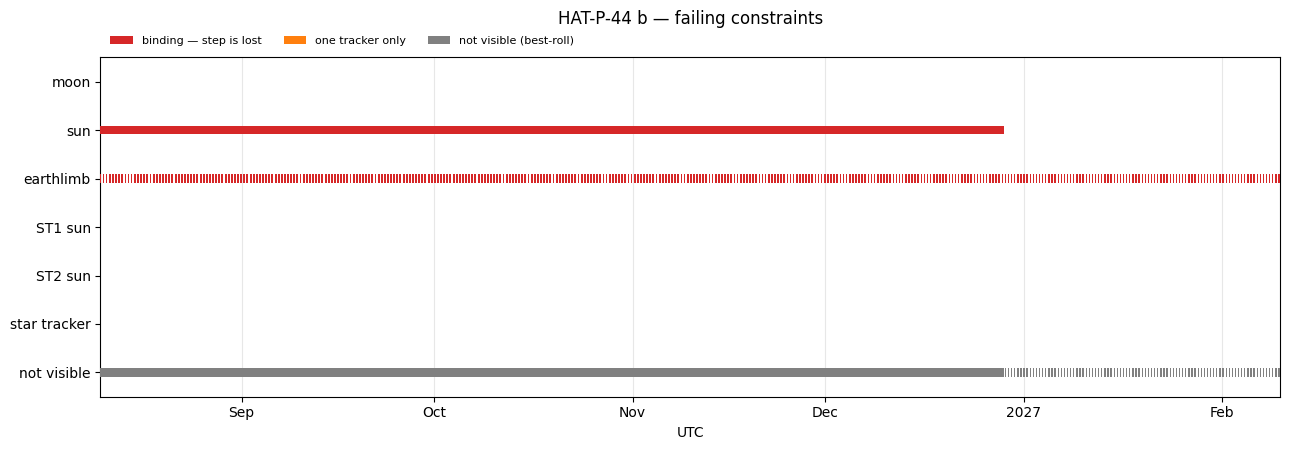

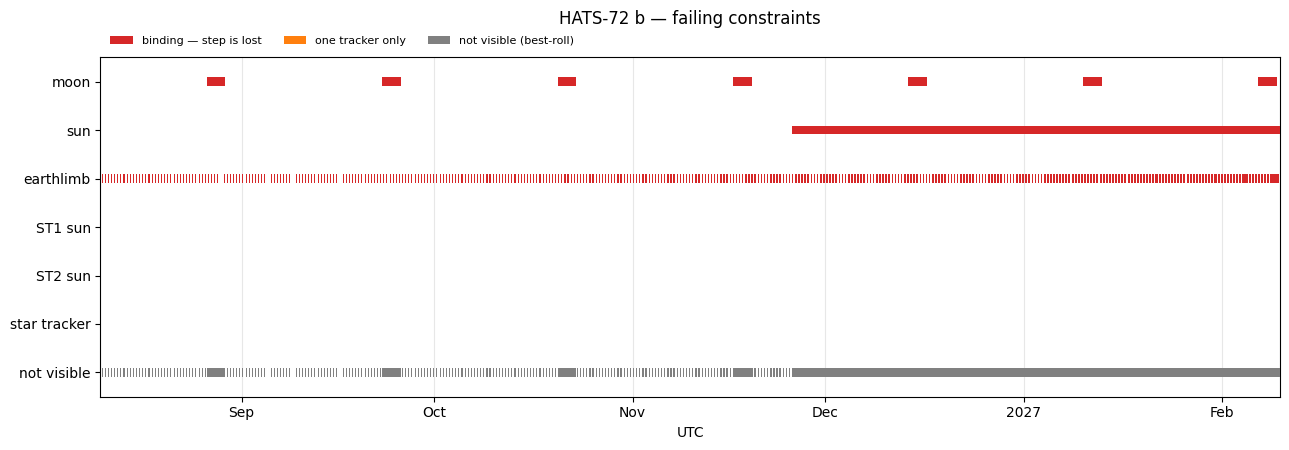

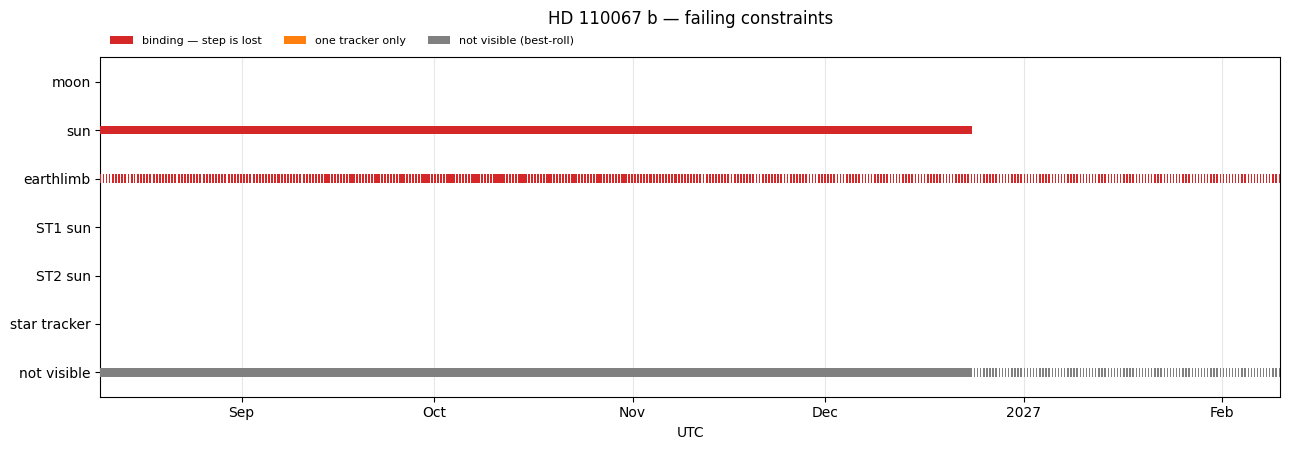

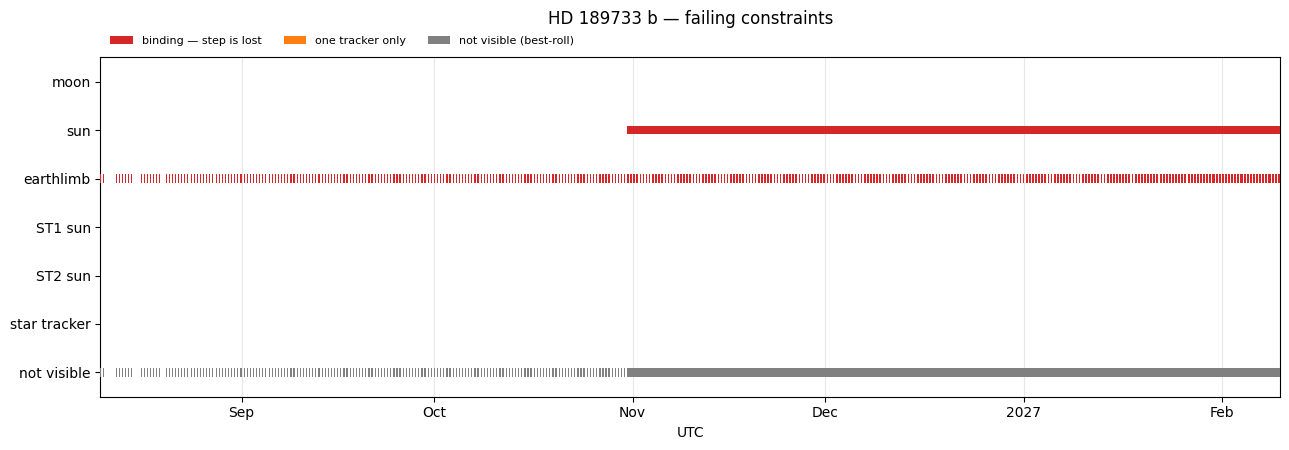

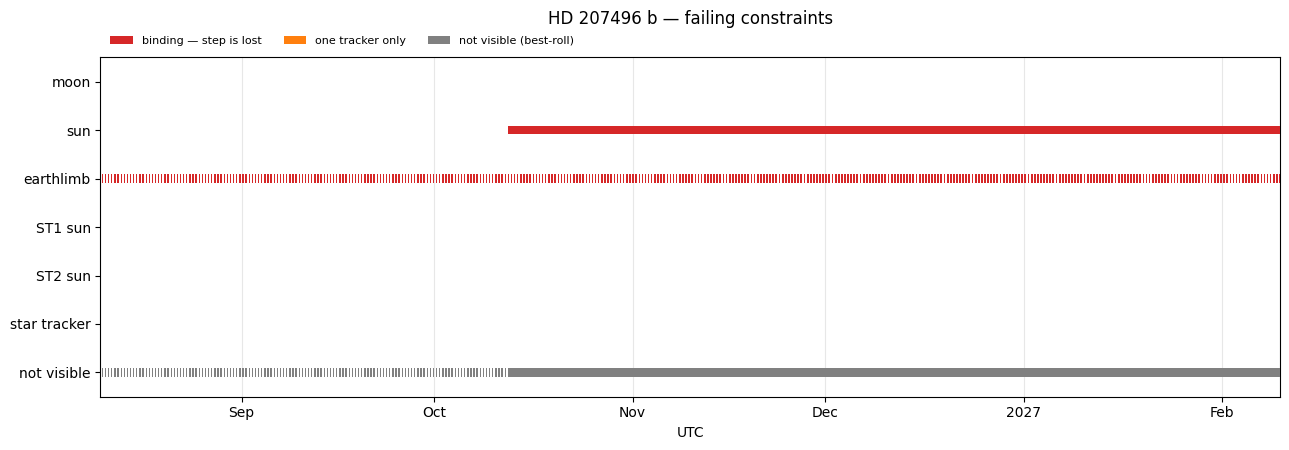

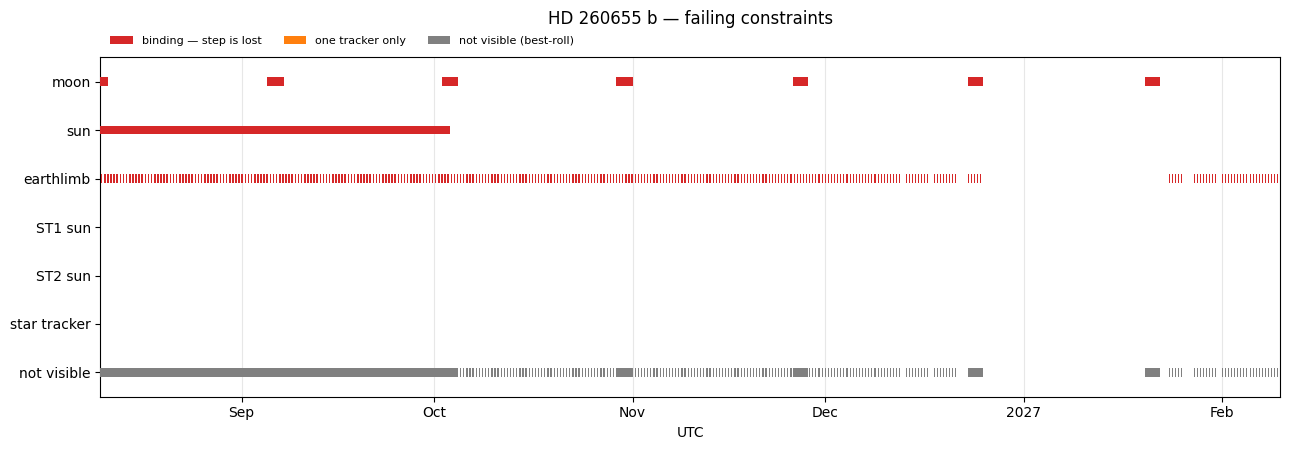

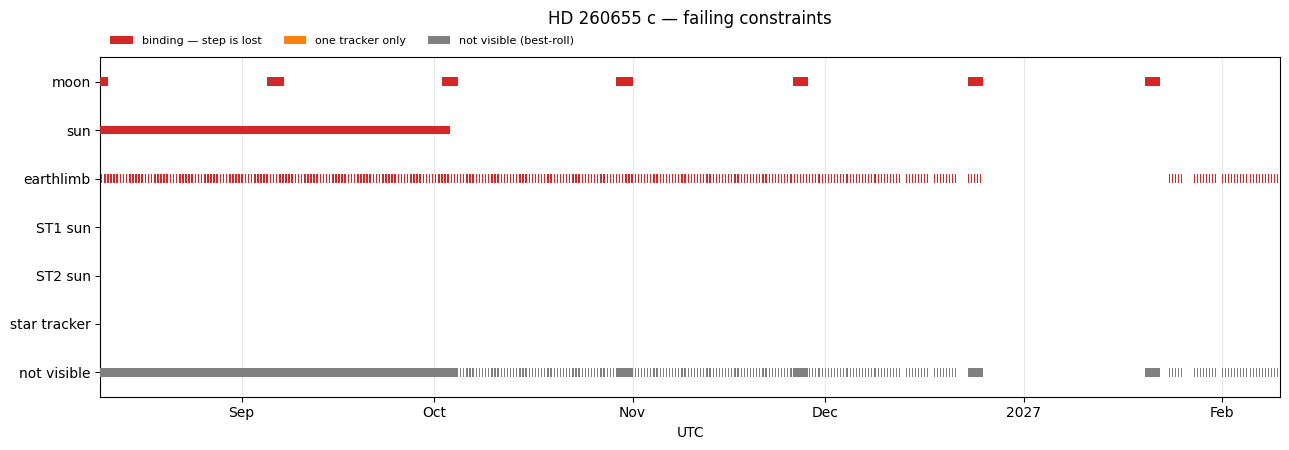

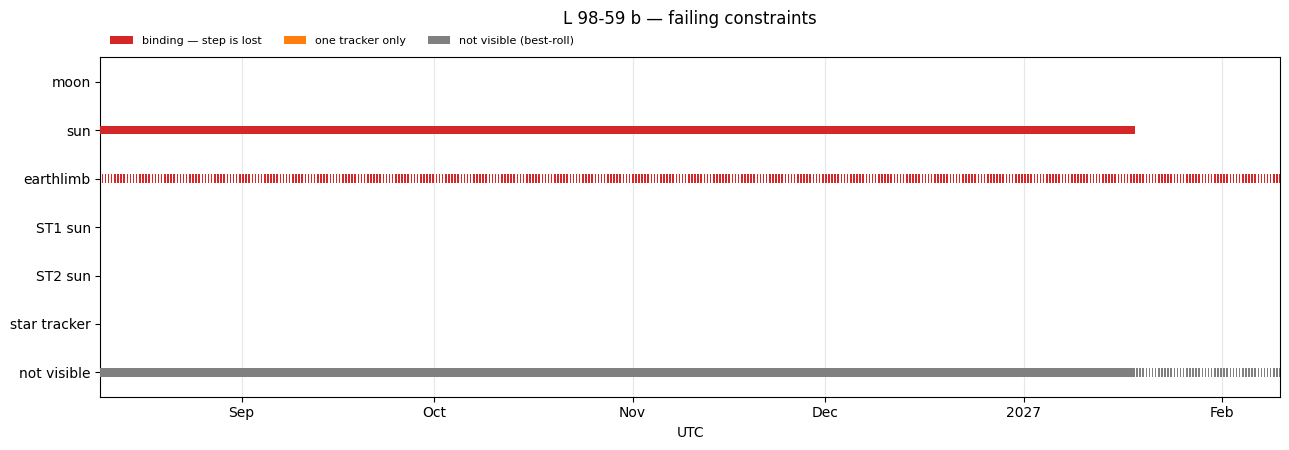

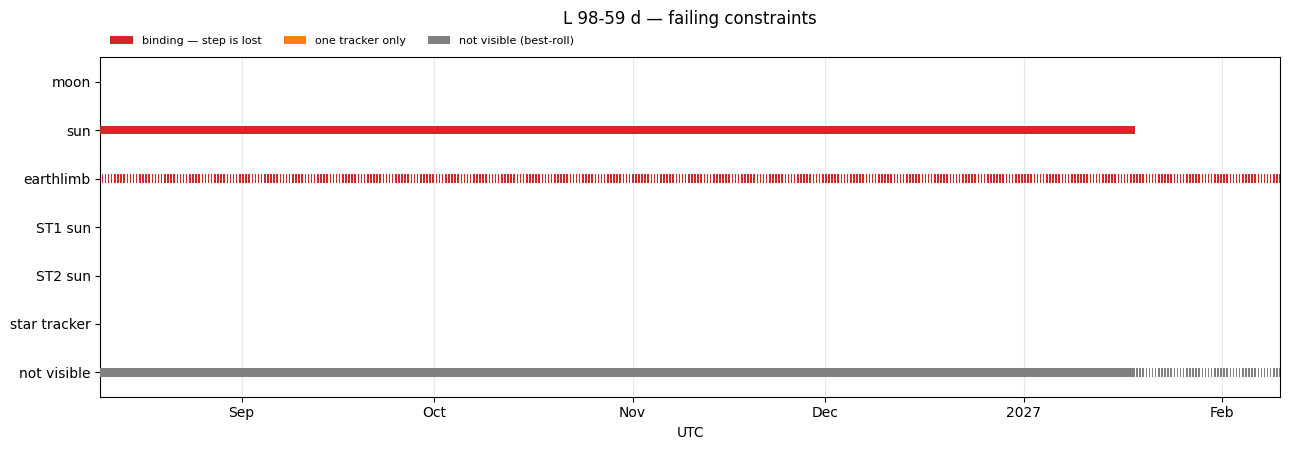

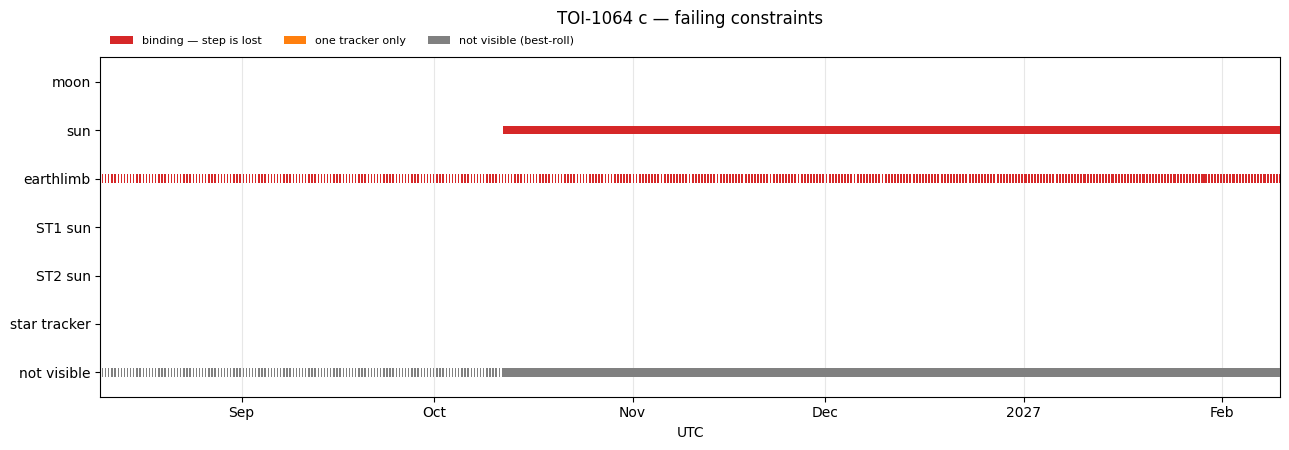

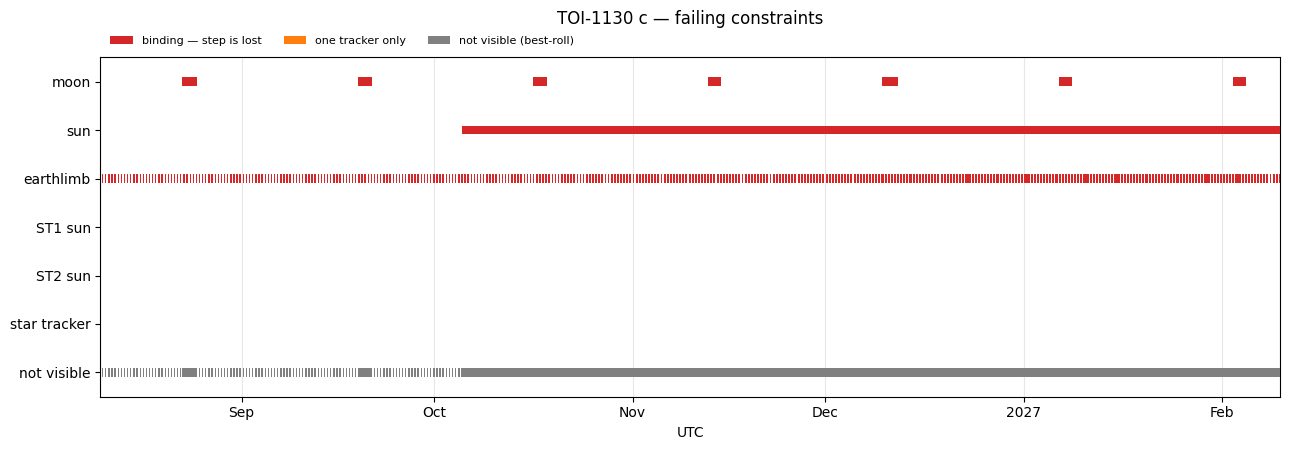

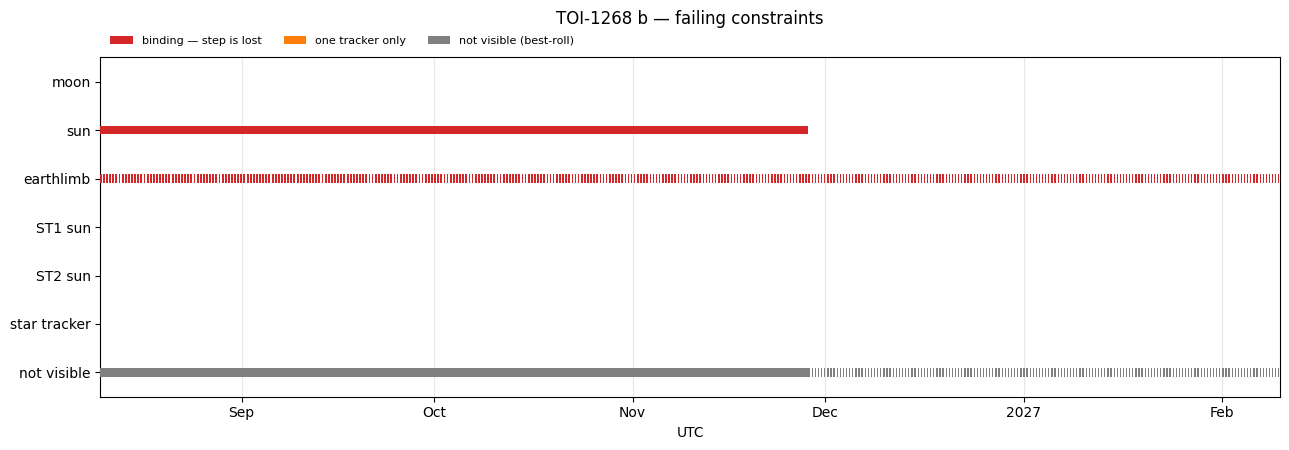

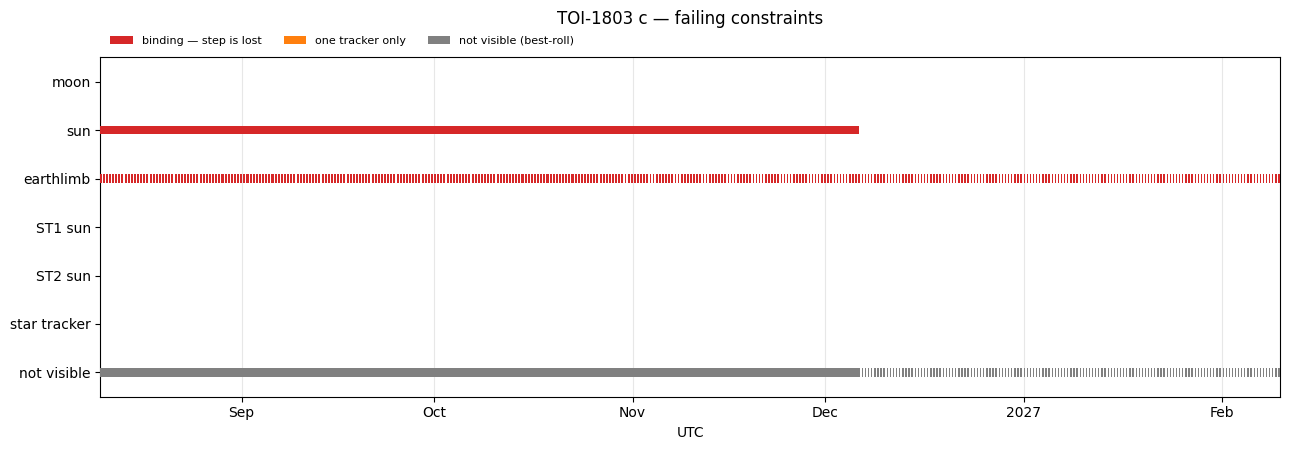

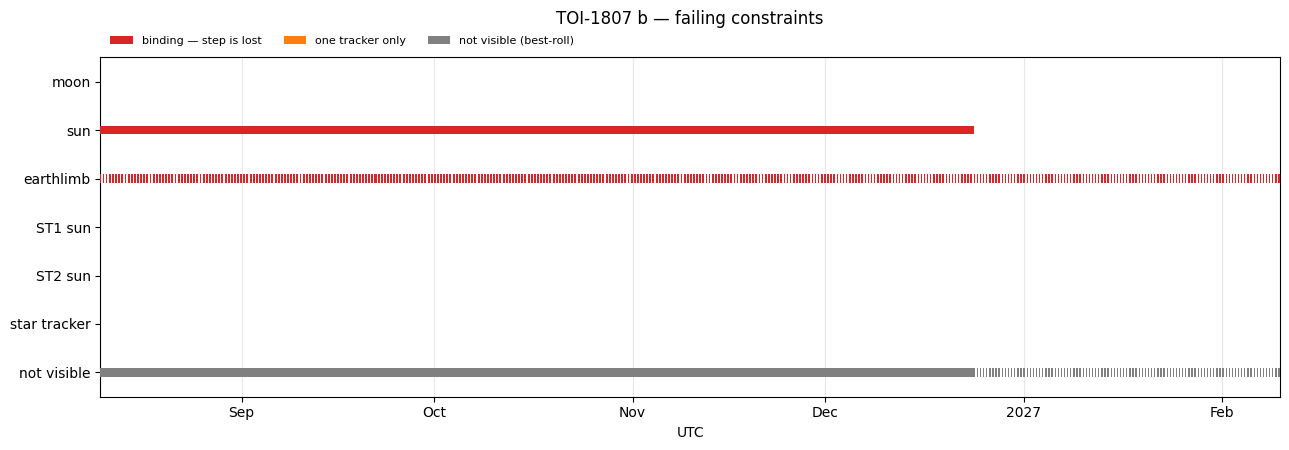

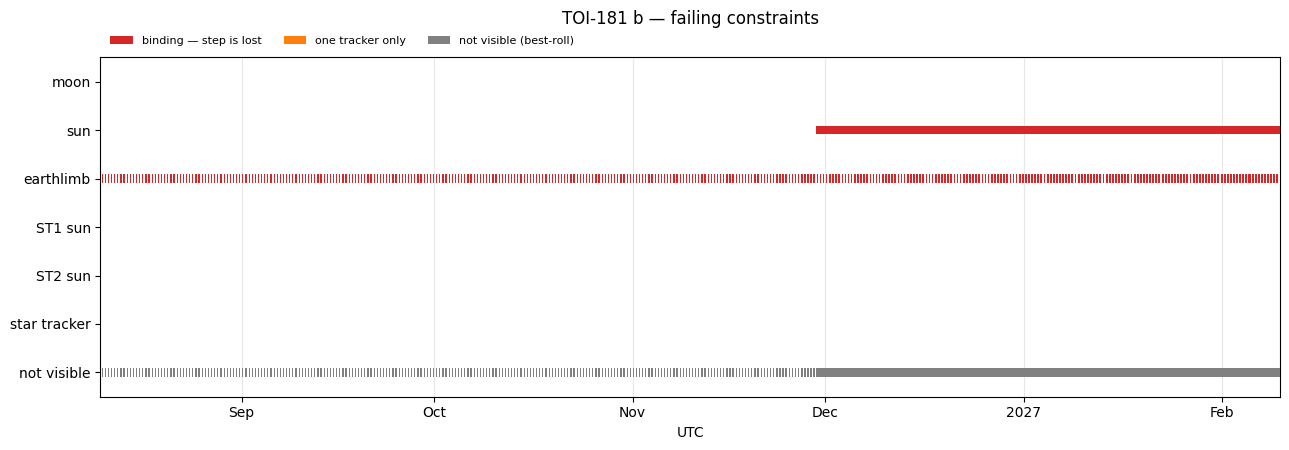

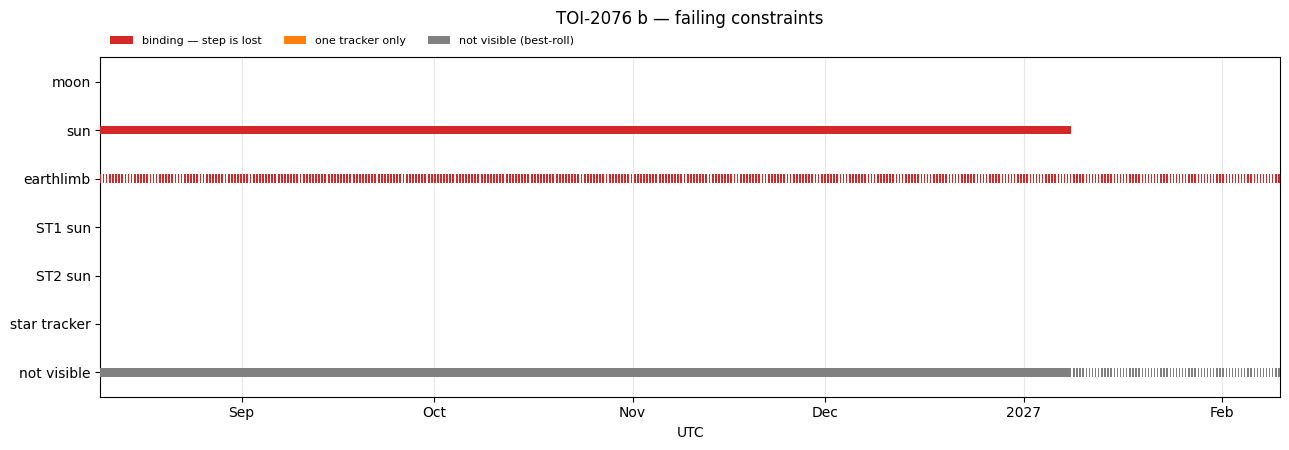

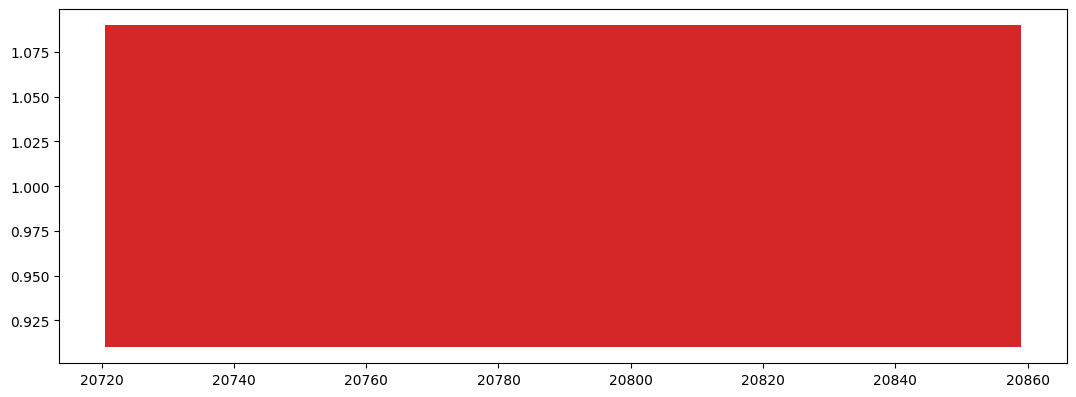

In [6]:
# Red marks a binding constraint: it failing is enough to lose the step.
# Amber marks one tracker failing one keep-out, which is only binding when
# no other tracker covers it — with st_required=1 the binding row is the
# combined "star tracker" one underneath.
BINDING_COLOR = "tab:red"
TRACKER_COLOR = "tab:orange"


targets_list = [
"WASP-29 b",
"WASP-52 b",
"WASP-69 b",
"WASP-80 b",
"WASP-84 b",
]

def format_limit(limit):
    """Render one keep-out limit, which may vary from step to step.

    Under ``use_dynamic_earthlimb_st`` the star tracker limb threshold
    follows the DPC wedge, so it is an array rather than a single angle;
    show its range in that case.
    """
    values = np.atleast_1d(limit.to_value(u.deg))
    if values.size > 1 and not np.allclose(values, values[0]):
        return f"{values.min():.0f}-{values.max():.0f}"
    return f"{values[0]:.0f}"


for label, result in results.items():
    constraints = visibility.get_all_constraints(result["coord"], times)
    breakdown = visibility.get_star_tracker_breakdown(result["coord"], times)
    not_visible = ~result["visible"]

    # Binding rows: the boresight bodies, plus the combined star tracker
    # verdict when trackers are active.
    binding = {
        name.replace("_", " "): ~np.asarray(passed)
        for name, passed in constraints.items()
    }
    # Per-tracker detail: one row per active check per tracker.  Shares
    # its geometry with the combined verdict above, so the rows always
    # add up.
    detail = {
        name: ~np.asarray(ok)
        for name, ok in breakdown["passed"].items()
        if name not in ("ST1", "ST2", "combined")
    }

    # "not visible" is explained by the binding rows only.
    explained = np.zeros_like(not_visible)
    for fail_mask in binding.values():
        explained |= fail_mask
    unexplained = int(np.sum(not_visible & ~explained))

    boresight = [n for n in binding if n != "star tracker"]
    st_rows = ["star tracker"] if "star tracker" in binding else []
    rows = boresight + list(detail) + st_rows + ["not visible"]

    fig, ax = plt.subplots(figsize=(13, 0.4 * len(rows) + 1.8))
    for row, name in enumerate(rows):
        if name == "not visible":
            mask, color = not_visible, "0.5"
        elif name in detail:
            mask, color = detail[name], TRACKER_COLOR
        else:
            mask, color = binding[name], BINDING_COLOR
        draw_row(ax, row, mask_segments(times, mask, time_step_minutes), color)

    label_rows(ax, rows)
    format_date_axis(ax, times)
    # The legend sits just above the axes, so lift the title clear of it —
    # same treatment as the visible-windows plot above.
    ax.set_title(f"{label} — failing constraints", pad=24 if detail else 6)
    if detail:
        handles = [
            Patch(facecolor=BINDING_COLOR, label="binding — step is lost"),
            Patch(facecolor=TRACKER_COLOR, label="one tracker only"),
            Patch(facecolor="0.5", label="not visible (best-roll)"),
        ]
        ax.legend(handles=handles, loc="lower left", bbox_to_anchor=(0.0, 1.005),
                  ncols=len(handles), fontsize=8, frameon=False)
    plt.tight_layout()

    print(f"{label}: not visible at {int(not_visible.sum())} of {len(times)} steps")
    for name in boresight:
        print(f"    {name:<14} fails at {int(binding[name].sum()):>5} steps")

    if detail:
        need = "both trackers" if visibility.st_required == 2 else "either tracker"
        print(f"    {'star tracker':<14} fails at "
              f"{int(binding['star tracker'].sum()):>5} steps  (needs {need})")
        for tracker in (1, 2):
            overall = ~np.asarray(breakdown["passed"][f"ST{tracker}"])
            print(f"      ST{tracker}{'':<11} fails at {int(overall.sum()):>5} steps")
            for name, mask in detail.items():
                if not name.startswith(f"ST{tracker} "):
                    continue
                check = name.split(" ", 1)[1]
                req = format_limit(breakdown["limits"][name])
                print(f"        {check:<10} < {req:>7} deg at "
                      f"{int(mask.sum()):>5} steps")

    if unexplained:
        print(f"    {unexplained} not-visible steps not explained by the above")